# 🌍 CO₂ Emissions & Economic Growth — EDA & Hypothesis Testing

**Author:** `Diana`  
**Date:** `27.05.2026`  
**Branch:** `Diana`

---
## Business Case

A coalition of environmental researchers is tracking whether the Paris Agreement has delivered measurable results. Using country-level data from 2014 to 2020, they investigate whether economic growth and carbon emissions are genuinely decoupling — or whether wealthy nations are simply exporting their footprint. The findings aim to hold regional climate commitments accountable with data.

### Hypothesis 1

> **Is GDP decoupling from CO2 emissions across regions from 2014 to 2020? — and does the answer change depending on how we measure emissions?**

Decoupling is measured by the CO2 intensity = CO2 emissions/GDP. This is tested in two scenarios: Scenario A uses fossil and industrial emissions only (co2 / GDP, the optimistic view); Scenario B adds land-use change (co2_luc / GDP, the honest view). If decoupling holds in Scenario A but weakens in Scenario B, it suggests wealthier regions have shifted emissions rather than eliminated them.

### Hypothesis 2

> **Where renewable energy adoption has grown, have CO₂ emissions actually fallen — and where is the gap largest?**

Following Hypothesis 1, we ask whether renewables presence drives the trend of CO2 emissions, being the mechanism use for the decoupling. We compare the trend of CO₂ emissions against the trend of renewable production share. Also, we distinguishing between what a region is producing from renewable sources versus what it actually consumed — as producing clean energy not consumed domestically is not decoupling.


### Hypothesis 3

> **Do high CO₂ emissions reflect development and improved living standards — or can they coexist with energy poverty, revealing that some countries are polluting on behalf of others?**

This links co2_per_cap to prct_access_elec across regions to identify countries in the high-emissions, low-access quadrant. We introduce a welfare_ratio (prct_access_elec / co2_per_cap) to measure how much energy benefit a population actually receives per unit of CO₂ emitted. If the lowest welfare ratios concentrate in the poorest nations, it means high emissions in the developing world are a symptom of economic exploitation — not a sign of growth.

---

## Notebook Purpose

This notebook covers:
1. **Exploratory Data Analysis (EDA)** — structure, distributions, regional patterns
2. **Hypothesis 1: CO₂ Intensity Analysis** — decoupling indicators per region (Scenarios A & B)
3. **Hypotehsis 2: CO₂ Renewable adoption vs. CO2 emissions** — CO2 emissions trend vs renewable share trends per region.
4. **Summary of Findings** — conclusions on hypothesis
5. **Known Limitations** — important caveats to pay attention to

**Input:** `../data/clean/merged_final.csv` (produced by the merge notebook)  
**Output:** Plots saved to `../figures/`, findings summarised in final markdown cell

---
## 0. Setup & Configuration

All paths and parameters are loaded from `config.yaml` to keep the notebook reproducible and environment-independent.  
Helper functions are imported from `functions.py` to keep this notebook clean and modular.

In [1]:
# libraries
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns


# ── Config ────────────────────────────────────────────────────────────────────
    
try:
    with open("../cfg.yaml", "r") as file:
        cfg = yaml.safe_load(file)
except:
    print("Yaml configuration file not found!")

---
## 1. Load Data

Loading the merged, cleaned dataset produced by the team merge notebook.  
We immediately validate shape, dtypes, and expected columns before proceeding.

In [2]:
#importing final dataframed cleaned and ready to work
f_df=pd.read_csv(cfg['output_data']['df3']) # ---> reading the final dataset cleaned df3 from yaml.cfg file
df=f_df.copy()
df.head(3)


,country,year,prct_access_elec,prct_renew_prod,renew_prod_kwh,prct_renew_cons,co2,co2_luc,prim_ener_cons,region,GDP,population,gdp_per_cap
0,Afghanistan,2014,89.5,2.772010,32440000.0,19.1,8.697668,8.776041,26.630217,Asia,1.950046e+10,32792523.0,594.661805
1,Afghanistan,2015,71.5,2.832290,33440000.0,17.7,9.384400,9.696866,30.953520,Asia,1.869957e+10,33831764.0,552.722397
2,Afghanistan,2016,97.7,3.190059,38660000.0,20.2,8.605932,8.944815,28.075348,Asia,1.822435e+10,34700612.0,525.188137


In [3]:
# ── Quick data quality check ──────────────────────────────────────────────────
print("Shape:", df.shape)
print("\nDtypes:")
print(df.dtypes)
print("\nNull counts:")
print(df.isnull().sum())

Shape: (1323, 13)

Dtypes:
country                 str
year                  int64
prct_access_elec    float64
prct_renew_prod     float64
renew_prod_kwh      float64
prct_renew_cons     float64
co2                 float64
co2_luc             float64
prim_ener_cons      float64
region                  str
GDP                 float64
population          float64
gdp_per_cap         float64
dtype: object

Null counts:
country             0
year                0
prct_access_elec    0
prct_renew_prod     0
renew_prod_kwh      0
prct_renew_cons     0
co2                 0
co2_luc             0
prim_ener_cons      0
region              0
GDP                 0
population          0
gdp_per_cap         0
dtype: int64


**Checkpoint:** Confirm the following before proceeding:
- [ ] Year range is 2014–2024
- [ ] Data types are consistent
- [ ] Key columns present: `country`, `year`, `co2`, `co2_luc`, `region`, `prim_ener_cons`,`prct_renew_prod`

---
## 2. Exploratory Data Analysis (EDA)

### 2.1 Hypothesis 1: scenario A

Has the CO₂ intensity of GDP (co2 / GDP) declined across regions from 2014 to 2020 — and does the answer change depending on how we measure emissions?

> **Scenario A: CO2 emissions considers only fossil and industrial emissions only (co2 / GDP)**

**CO2 intensity metric (`co2_int`)**: `co2 / GDP` - the decoupling indicator. Shows how much carbon is emitted per unit of economic output. A declining trend means the economy is growing greener.


In [4]:
# Computing the CO2 intensity indicator:
#co2 is measured in million tonnes and GDP is in international-$ in 2011 prices ($)
df['co2_int'] = df['co2']/df['GDP'] #--> Units (MtCO₂ / USD)
df.head(1)


,country,year,prct_access_elec,prct_renew_prod,renew_prod_kwh,prct_renew_cons,co2,co2_luc,prim_ener_cons,region,GDP,population,gdp_per_cap,co2_int
0,Afghanistan,2014,89.5,2.77201,32440000.0,19.1,8.697668,8.776041,26.630217,Asia,1.950046e+10,32792523.0,594.661805,4.460237e-10


In [5]:
# Initial study by country of the top and bottom 10 countries by co2_intensity and percentage of renewable share:
country_avg = df.groupby('country')[['co2_int', 'prct_renew_prod']].mean()

top10_co2_int    = country_avg.sort_values('co2_int', ascending=False).head(10)
top10_renew_prod    = country_avg.sort_values('prct_renew_prod', ascending=False).head(10)
print("Top 10 co2_intensity [CO2/USD]:\n", top10_co2_int['co2_int']*1000000)
print("________")
print("\nTop 10 renewable share [%]:\n", round(top10_renew_prod['prct_renew_prod'],2))


Top 10 co2_intensity [CO2/USD]:
 country
Tanzania               0.004814
North Korea            0.003177
Mongolia               0.002806
Ukraine                0.001918
Iran                   0.001800
Kazakhstan             0.001745
Trinidad and Tobago    0.001681
Syria                  0.001607
Turkmenistan           0.001549
Uzbekistan             0.001477
Name: co2_int, dtype: float64
________

Top 10 renewable share [%]:
 country
Denmark        68.51
Nicaragua      47.99
Kenya          47.81
Uruguay        43.26
Eswatini       43.00
El Salvador    42.41
Lithuania      40.31
Belize         32.55
Germany        30.53
Portugal       30.47
Name: prct_renew_prod, dtype: float64


In [6]:
# Computing the rate of decoupling from CO2
#to use diff method, we need to order the years accordingly
df= df.sort_values(['country', 'year']).reset_index(drop=True)
# Now that they are ordered, we compute the delta (delta = year - previous year data).
df['d_co2_int']= df.groupby('country')['co2_int'].diff() ## for the first year it give NaN
df.head(3)

,country,year,prct_access_elec,prct_renew_prod,renew_prod_kwh,prct_renew_cons,co2,co2_luc,prim_ener_cons,region,GDP,population,gdp_per_cap,co2_int,d_co2_int
0,Afghanistan,2014,89.5,2.772010,32440000.0,19.1,8.697668,8.776041,26.630217,Asia,1.950046e+10,32792523.0,594.661805,4.460237e-10,NaN
1,Afghanistan,2015,71.5,2.832290,33440000.0,17.7,9.384400,9.696866,30.953520,Asia,1.869957e+10,33831764.0,552.722397,5.018510e-10,5.582731e-11
2,Afghanistan,2016,97.7,3.190059,38660000.0,20.2,8.605932,8.944815,28.075348,Asia,1.822435e+10,34700612.0,525.188137,4.722216e-10,-2.962940e-11


<Axes: title={'center': 'co2_int'}, xlabel='region'>

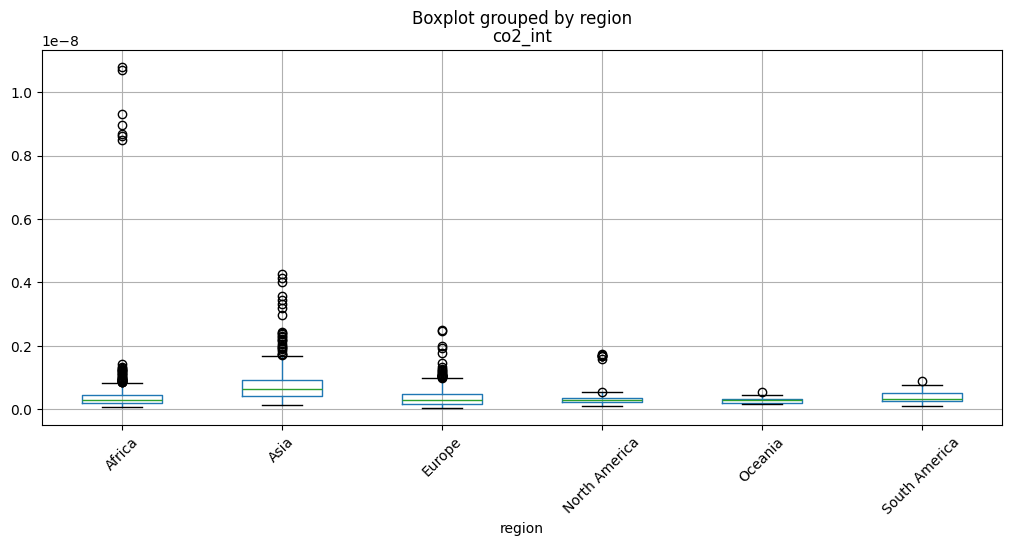

In [7]:
#building the box plot for the data around region.
df.boxplot(column='co2_int', by='region', figsize=(12,5), rot=45)

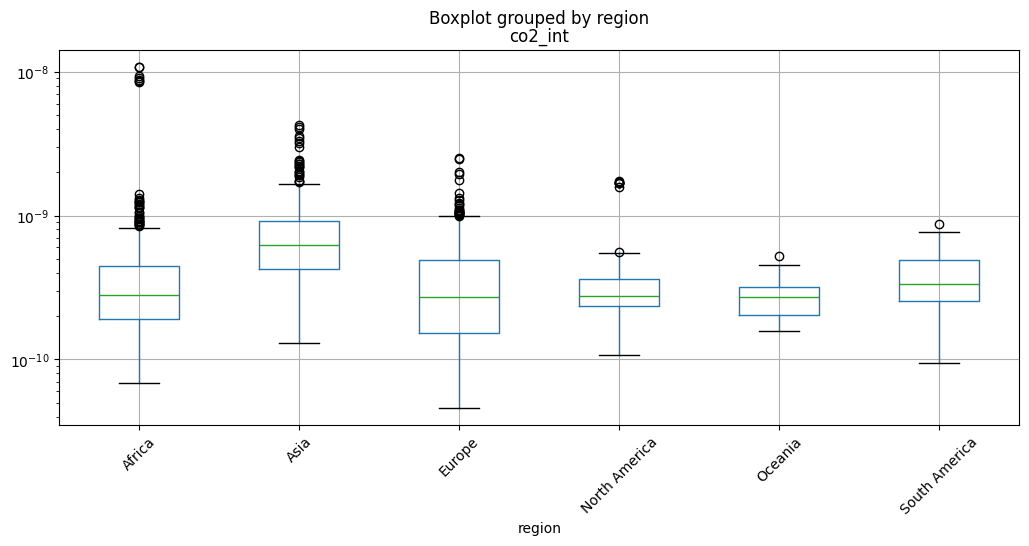

In [8]:
#the scale for every region is different, specially considering Africa with extreme outliers, we fix the visual by 
#adjusting the plot scale:
import matplotlib.pyplot as plt

df.boxplot(column='co2_int', by='region', figsize=(12,5), rot=45)
plt.yscale('log') # This spreads out the squished boxes at the bottom
plt.savefig('../figures/boxplot_outliers_Regions.png', dpi=150, bbox_inches='tight')
plt.show()


#### 2.1.1 Hypothesis 1: scenario A - CO2 intensity through median metric


In [9]:
#selecting just the columns of interest for the CO2 decoupling analysis.
dec_cols=['country', 'year','region','co2_int', 'd_co2_int']
dec_df=df[dec_cols]
dec_df.head(1)


,country,year,region,co2_int,d_co2_int
0,Afghanistan,2014,Asia,4.460237e-10,NaN


In [10]:
piv_dec_df= dec_df.pivot_table(index='year', columns='region', values='co2_int', aggfunc='median')
piv_dec_df.head(2)


region,Africa,Asia,Europe,North America,Oceania,South America
year,,,,,,
2014,2.331501e-10,5.048535e-10,2.698633e-10,2.945257e-10,2.466248e-10,3.157920e-10
2015,2.769143e-10,6.402478e-10,3.169185e-10,2.981302e-10,2.829628e-10,3.236926e-10


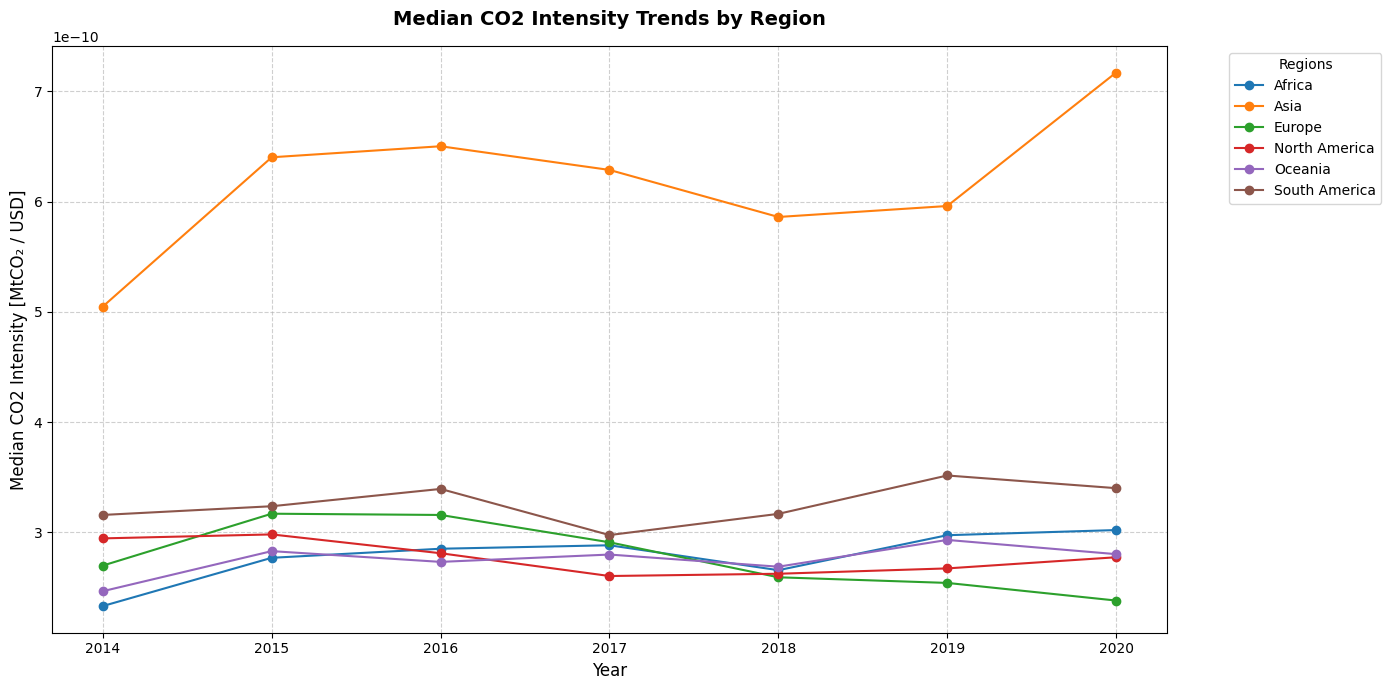

In [11]:
#creating the line plot to see CO2 intensity trend per region
piv_dec_df.plot(kind='line', figsize=(14,7), marker='o')
# Adding clear lables and titles
plt.title('Median CO2 Intensity Trends by Region', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Median CO2 Intensity [MtCO₂ / USD]', fontsize=12)

#Working the layout and legend
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Regions', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../figures/medianCO2Intensity_Regiontrends.png', dpi=150, bbox_inches='tight')
#Rendering the final image
plt.show()



#### 2.1.2 Hypothesis 1: scenario A - CO2 intensity through mean metric


In [12]:
piv2_dec_df= dec_df.pivot_table(index='year', columns='region', values='co2_int', aggfunc='mean')
piv2_dec_df

region,Africa,Asia,Europe,North America,Oceania,South America
year,,,,,,
2014,4.668765e-10,6.954938e-10,3.829745e-10,3.547341e-10,2.653889e-10,3.465572e-10
2015,5.470020e-10,7.440496e-10,4.519618e-10,3.663301e-10,2.959221e-10,3.568485e-10
2016,5.655914e-10,7.986319e-10,4.526765e-10,3.608283e-10,2.856471e-10,3.995574e-10
2017,5.254072e-10,8.357430e-10,4.132040e-10,3.442618e-10,2.706516e-10,3.601619e-10
2018,4.964014e-10,8.240533e-10,3.699191e-10,3.396589e-10,2.674826e-10,3.491505e-10
2019,5.182350e-10,8.363627e-10,3.486078e-10,3.491992e-10,2.733962e-10,3.861752e-10
2020,5.191493e-10,8.794269e-10,3.335929e-10,3.439745e-10,2.788740e-10,4.020666e-10


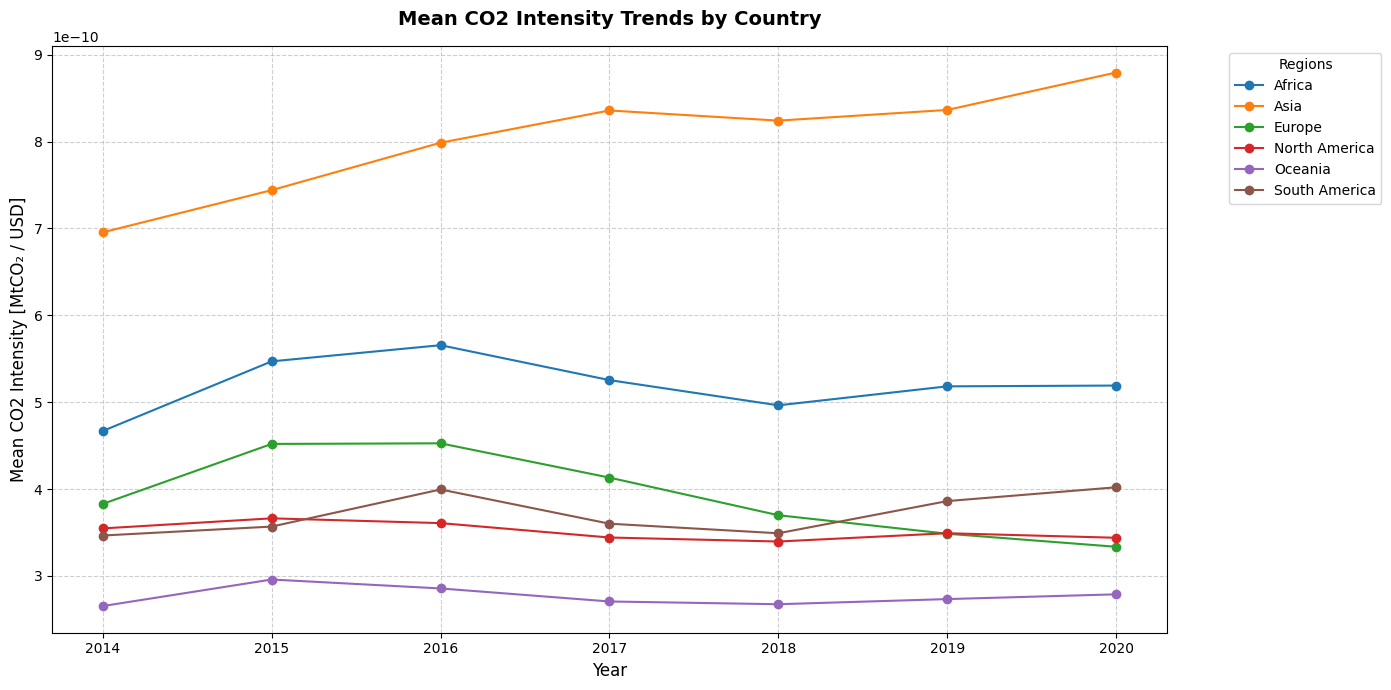

In [13]:
#creating the line plot to see CO2 intensity trend per region
piv2_dec_df.plot(kind='line', figsize=(14,7), marker='o')
# Adding clear lables and titles
plt.title('Mean CO2 Intensity Trends by Country', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Mean CO2 Intensity [MtCO₂ / USD]', fontsize=12)

#Working the layout and legend
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Regions', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
#Rendering the final image
plt.show()

In [14]:
dec_df.head(1)

,country,year,region,co2_int,d_co2_int
0,Afghanistan,2014,Asia,4.460237e-10,NaN


In [15]:
#constructing a function to spot ouliers per region using the Interquartile Range (IQR) as a boxplot would do.

#outliers (from boxplot) are calculated as: lower outliers Q1 - 1.5*IQR & upper ouliers Q3 + 1,5*IQR
#then we need Q1,Q2 and IQR (box hight in the boxplot). IQR is calculated as: Q3-Q1
#IQR is computed per region per ALL years combined — not per region per year, to have stable outlier 
#flag.

#Calculate Q1 and Q3 per region using transform, using .apply deleted my column region! :(
q1_p_reg = dec_df.groupby('region')['co2_int'].transform(lambda x: x.quantile(0.25))
q3_p_reg = dec_df.groupby('region')['co2_int'].transform(lambda x: x.quantile(0.75))

# Calculate IQR based on those regional series
iqr_p_reg = q3_p_reg - q1_p_reg

#Create outlier flag column 
dec_df['outlier'] = (dec_df['co2_int'] < q1_p_reg - 1.5 * iqr_p_reg) |(dec_df['co2_int'] > q3_p_reg + 1.5 * iqr_p_reg)

dec_df.head(5)

,country,year,region,co2_int,d_co2_int,outlier
0,Afghanistan,2014,Asia,4.460237e-10,NaN,False
1,Afghanistan,2015,Asia,5.018510e-10,5.582731e-11,False
2,Afghanistan,2016,Asia,4.722216e-10,-2.962940e-11,False
3,Afghanistan,2017,Asia,4.891723e-10,1.695069e-11,False
4,Afghanistan,2018,Asia,5.404821e-10,5.130980e-11,False


In [16]:
display(dec_df[dec_df['outlier'] == True].country.unique())

<StringArray>
[               'Algeria',                'Belarus', 'Bosnia and Herzegovina',
                  'Egypt',                   'Iran',                'Jamaica',
             'Kazakhstan',                'Lesotho',                  'Libya',
               'Mongolia',                  'Nauru',            'North Korea',
                 'Russia',                 'Serbia',           'South Africa',
               'Suriname',                  'Syria',               'Tanzania',
    'Trinidad and Tobago',           'Turkmenistan',                'Ukraine',
             'Uzbekistan']
Length: 22, dtype: str

In [17]:
#Now we can compare mean with and without outliers.
df_w    = dec_df.copy() # ->> dataframe with outlier countries
df_wo = dec_df[dec_df['outlier'] == False].copy() #--> dataframe without the oulier countries

piv_w = df_w.pivot_table(index='year', columns='region', values='co2_int', aggfunc='mean')
piv_wo = df_wo.pivot_table(index='year', columns='region', values='co2_int', aggfunc='mean')


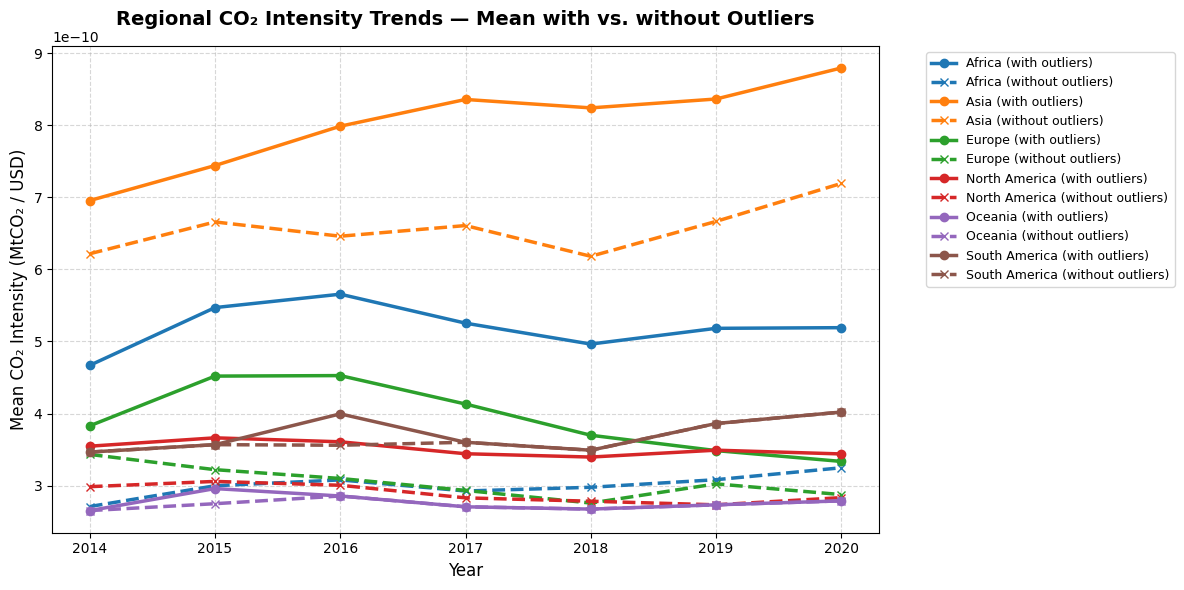

In [18]:
fig, ax = plt.subplots(figsize=(12, 6))

# Color per region — same color both lines
colors = plt.cm.tab10.colors

# Loop through columns (regions)
for i, region in enumerate(piv_w.columns):
    
    #Plot 'with outliers' -> X-axis is the index (years), Y-axis is the region column
    ax.plot(piv_w.index, piv_w[region],
            color=colors[i], linewidth=2.5, linestyle='-',
            marker='o', label=f'{region} (with outliers)')
    
    #Plot 'without outliers' -> X-axis is the index (years), Y-axis is the region column
    ax.plot(piv_wo.index, piv_wo[region],
            color=colors[i], linewidth=2.5, linestyle='--',
            marker='x', label=f'{region} (without outliers)')

# Formatting the labels and layout
ax.set_title('Regional CO₂ Intensity Trends — Mean with vs. without Outliers', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Mean CO₂ Intensity (MtCO₂ / USD)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5)

# Clear X-axis ticks for each year
ax.set_xticks(piv_w.index)

# Handle the legend outside to the right
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('../figures/h1_outlier_comparison.png', dpi=150, bbox_inches='tight')
plt.show()




#### 2.1.3 Hypothesis 1: scenario A - CO2 intensity endpoint delta


In [19]:
# get 2014 and 2020 values per country
endpoint = dec_df[dec_df['year'].isin([2014, 2020])]
endpoint = endpoint.pivot_table(index=['region','country'], columns='year', values='co2_int')
endpoint.head(2)


year                    2014          2020
region country                            
Africa Algeria  6.379550e-10  1.038000e-09
       Angola   1.586647e-10  2.487850e-10

In [20]:
endpoint.columns = ['co2_int_2014', 'co2_int_2020']
endpoint['delta'] = endpoint['co2_int_2020'] - endpoint['co2_int_2014']


In [21]:
endpoint.head(1)

,,co2_int_2014,co2_int_2020,delta
region,country,,,
Africa,Algeria,6.379550e-10,1.038000e-09,4.000446e-10


In [22]:
display(endpoint.isnull().any())

co2_int_2014    False
co2_int_2020    False
delta           False
dtype: bool

/var/folders/y7/p6n8z7nn4fs88vn9n57nxbh40000gn/T/ipykernel_27962/809403113.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


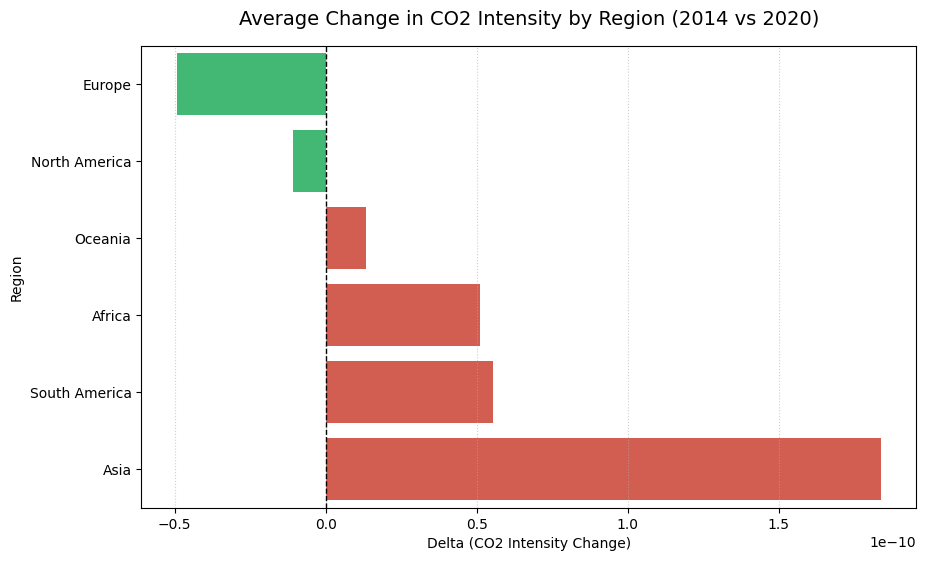

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# aggregating data y region (averaging or summing the delta)
region_delta = endpoint.groupby('region')['delta'].mean().sort_values().reset_index()

# Plotting
plt.figure(figsize=(10, 6))
# Fixing colors to show good or bad shift, green for negative delta (decline), red for positive (increase)
colors = ['#2ecc71' if x < 0 else '#e74c3c' for x in region_delta['delta']]

sns.barplot(
    x='delta', 
    y='region', 
    data=region_delta, 
    palette=colors
)

plt.axvline(x=0, color='black', linestyle='--', linewidth=1) # Zero line
plt.title('Average Change in CO2 Intensity by Region (2014 vs 2020)', fontsize=14, pad=15)
plt.xlabel('Delta (CO2 Intensity Change)')
plt.ylabel('Region')
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.savefig('../figures/AvgChange_CO2intens_Regions.png', dpi=150, bbox_inches='tight')
plt.show()

 ### 2.2 Hypothesis 1: scenario B

Has the CO₂ intensity of GDP (co2 / GDP) declined across regions from 2014 to 2020 — and does the answer change depending on how we measure emissions?

> **Scenario B: CO2 emissions including land-use change (co2_luc / GDP)**

**CO₂ with land-use intensity (co2_luc_int)**: co2_luc / GDP — same decoupling logic as Scenario A, but the honest view that includes land-use change emissions.
**Delta of CO₂ intensity with land-use (d_co2_luc_int)**: year-over-year change in co2_luc_int per country.

In [24]:
# Computing the CO2 intensity indicator:
#co2 is measured in million tonnes and GDP is in international-$ in 2011 prices ($)
df['co2_luc_int'] = df['co2_luc']/df['GDP'] #--> scenario B
df.head(2)

,country,year,prct_access_elec,prct_renew_prod,renew_prod_kwh,prct_renew_cons,co2,co2_luc,prim_ener_cons,region,GDP,population,gdp_per_cap,co2_int,d_co2_int,co2_luc_int
0,Afghanistan,2014,89.5,2.77201,32440000.0,19.1,8.697668,8.776041,26.630217,Asia,1.950046e+10,32792523.0,594.661805,4.460237e-10,NaN,4.500427e-10
1,Afghanistan,2015,71.5,2.83229,33440000.0,17.7,9.384400,9.696866,30.953520,Asia,1.869957e+10,33831764.0,552.722397,5.018510e-10,5.582731e-11,5.185608e-10


#### 2.2.1 Hypothesis 1: scenario B - CO2 intensity through median metric

In [25]:
#selecting just the columns of interest for the CO2 decoupling analysis.
dec_luc_cols=['country', 'year','region','co2_luc_int']
dec_luc_df=df[dec_luc_cols]
dec_luc_df.head(1)


,country,year,region,co2_luc_int
0,Afghanistan,2014,Asia,4.500427e-10


In [26]:
piv_dec_luc_df= dec_luc_df.pivot_table(index='year', columns='region', values='co2_luc_int', aggfunc='median')
piv_dec_luc_df.head(2)

region,Africa,Asia,Europe,North America,Oceania,South America
year,,,,,,
2014,1.167092e-09,7.410631e-10,2.380242e-10,3.773317e-10,3.557506e-10,7.045899e-10
2015,1.319323e-09,8.467164e-10,2.586556e-10,2.963745e-10,3.932691e-10,5.965803e-10


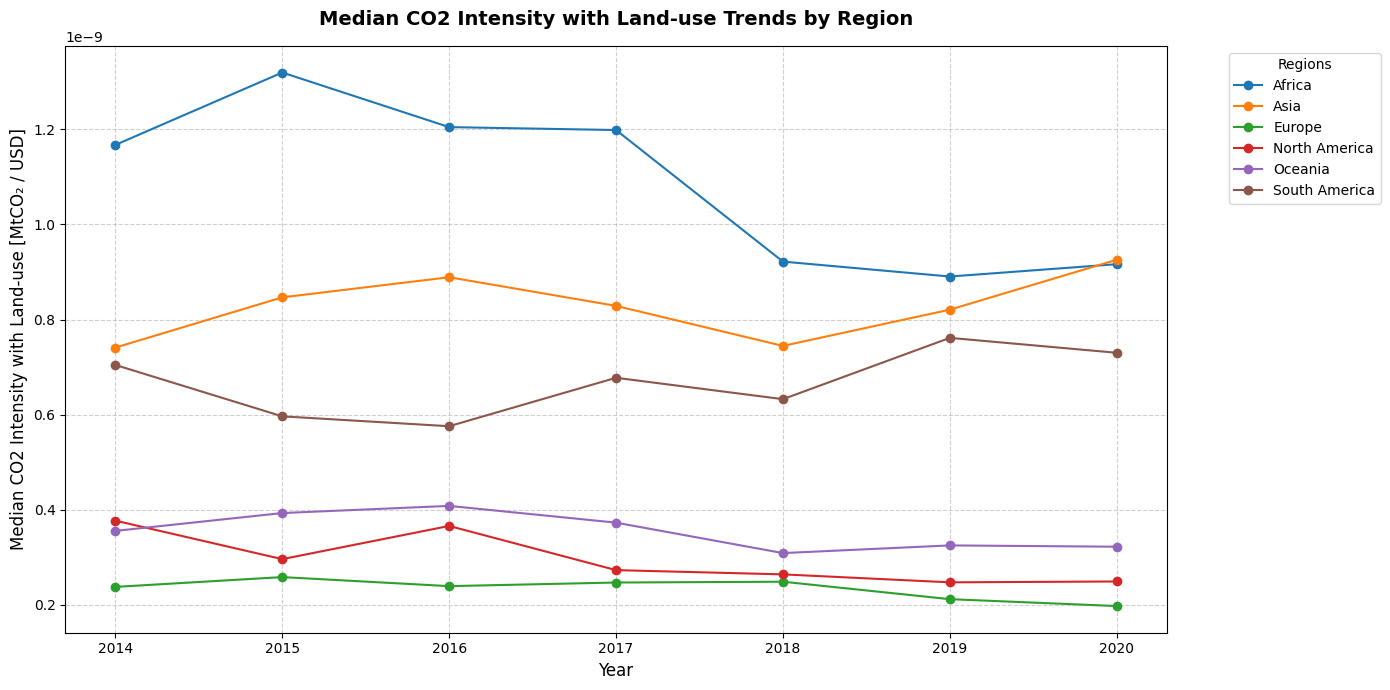

In [27]:
#creating the line plot to see CO2 intensity trend per region
piv_dec_luc_df.plot(kind='line', figsize=(14,7), marker='o')
# Adding clear lables and titles
plt.title('Median CO2 Intensity with Land-use Trends by Region', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Median CO2 Intensity with Land-use [MtCO₂ / USD]', fontsize=12)

#Working the layout and legend
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Regions', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../figures/medianCO2Intensity_luc_Regiontrends.png', dpi=150, bbox_inches='tight')
#Rendering the final image
plt.show()


#### 2.1.2 Hypothesis 1: scenario B - CO2 intensity through mean metric

In [28]:
#constructing a function to spot ouliers per region using the Interquartile Range (IQR) as a boxplot would do.

#outliers (from boxplot) are calculated as: lower outliers Q1 - 1.5*IQR & upper ouliers Q3 + 1,5*IQR
#then we need Q1,Q2 and IQR (box hight in the boxplot). IQR is calculated as: Q3-Q1
#IQR is computed per region per ALL years combined — not per region per year, to have stable outlier 
#flag.

#Calculate Q1 and Q3 per region using transform, using .apply deleted my column region! :(
q1luc_p_reg = dec_luc_df.groupby('region')['co2_luc_int'].transform(lambda x: x.quantile(0.25))
q3luc_p_reg = dec_luc_df.groupby('region')['co2_luc_int'].transform(lambda x: x.quantile(0.75))

# Calculate IQR based on those regional series
iqrluc_p_reg = q3luc_p_reg - q1luc_p_reg

#Create outlier flag column 
dec_luc_df['outlier'] = (dec_luc_df['co2_luc_int'] < q1luc_p_reg - 1.5 * iqrluc_p_reg) |(dec_luc_df['co2_luc_int'] > q3luc_p_reg + 1.5 * iqrluc_p_reg)

dec_luc_df.head(2)

,country,year,region,co2_luc_int,outlier
0,Afghanistan,2014,Asia,4.500427e-10,False
1,Afghanistan,2015,Asia,5.185608e-10,False


In [29]:
display(dec_luc_df[dec_luc_df['outlier'] == True].country.unique())

<StringArray>
[                     'Belarus',                       'Belize',
                       'Bhutan',                      'Bolivia',
       'Bosnia and Herzegovina',     'Central African Republic',
                'Cote d'Ivoire', 'Democratic Republic of Congo',
                   'East Timor',                       'Guinea',
                       'Guyana',                     'Honduras',
                         'Laos',                      'Liberia',
                     'Mongolia',                   'Montenegro',
                    'Nicaragua',                  'North Korea',
              'North Macedonia',             'Papua New Guinea',
                       'Russia',                        'Samoa',
              'Solomon Islands',                  'South Sudan',
                     'Tanzania',          'Trinidad and Tobago',
                      'Ukraine',                      'Vanuatu']
Length: 28, dtype: str

In [30]:
#Now we can compare mean with and without outliers.
df_luc_w    = dec_luc_df.copy() # ->> dataframe with outlier countries
df_luc_wo = dec_luc_df[dec_luc_df['outlier'] == False].copy() #--> dataframe without the oulier countries

piv_luc_w = df_luc_w.pivot_table(index='year', columns='region', values='co2_luc_int', aggfunc='mean')
piv_luc_wo = df_luc_wo.pivot_table(index='year', columns='region', values='co2_luc_int', aggfunc='mean')


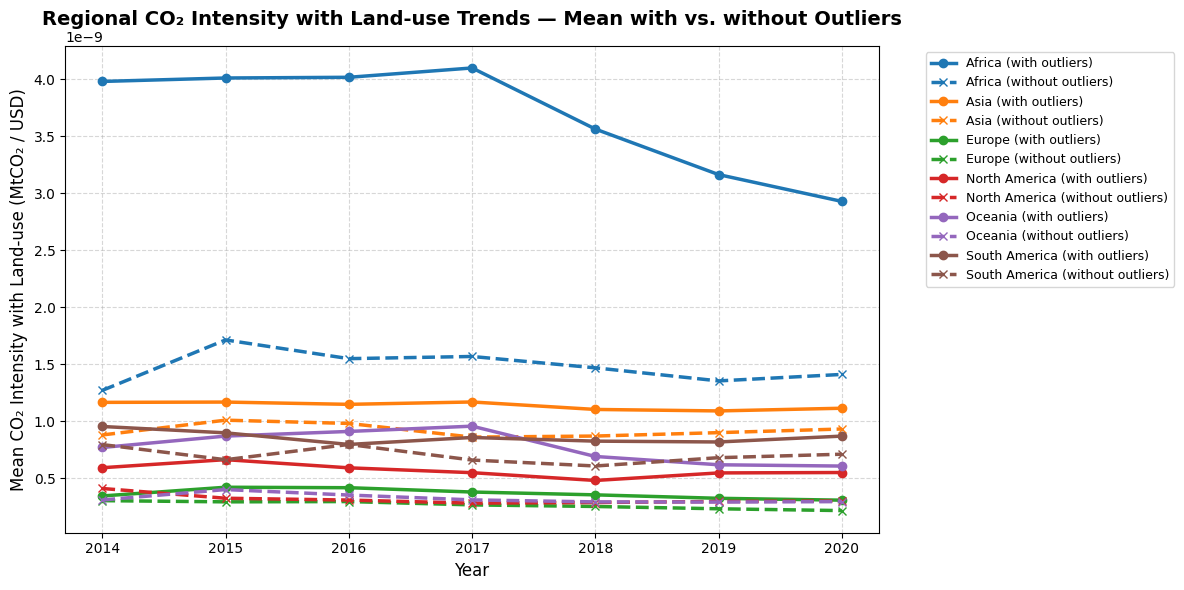

In [31]:
fig, ax = plt.subplots(figsize=(12, 6))

# Color per region — same color both lines
colors = plt.cm.tab10.colors

# Loop through columns (regions)
for i, region in enumerate(piv_luc_w.columns):
    
    #Plot 'with outliers' -> X-axis is the index (years), Y-axis is the region column
    ax.plot(piv_luc_w.index, piv_luc_w[region],
            color=colors[i], linewidth=2.5, linestyle='-',
            marker='o', label=f'{region} (with outliers)')
    
    #Plot 'without outliers' -> X-axis is the index (years), Y-axis is the region column
    ax.plot(piv_luc_wo.index, piv_luc_wo[region],
            color=colors[i], linewidth=2.5, linestyle='--',
            marker='x', label=f'{region} (without outliers)')

# Formatting the labels and layout
ax.set_title('Regional CO₂ Intensity with Land-use Trends — Mean with vs. without Outliers', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Mean CO₂ Intensity with Land-use (MtCO₂ / USD)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5)

# Clear X-axis ticks for each year
ax.set_xticks(piv_luc_w.index)

# Handle the legend outside to the right
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('../figures/h1_LUCoutlier_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


#### 2.1.3 Hypothesis 1: scenario B - CO2 intensity endpoint delta

In [32]:
# get 2014 and 2020 values per country
endpoint_luc = dec_luc_df[dec_luc_df['year'].isin([2014, 2020])]
endpoint_luc = endpoint_luc.pivot_table(index=['region','country'], columns='year', values='co2_luc_int')
endpoint_luc.head(2)

year                    2014          2020
region country                            
Africa Algeria  6.496779e-10  1.047707e-09
       Angola   7.823051e-10  1.058501e-09

In [33]:
endpoint_luc.columns = ['co2_luc_int_2014', 'co2_luc_int_2020']


In [34]:
endpoint_luc['delta'] = endpoint_luc['co2_luc_int_2020'] - endpoint_luc['co2_luc_int_2014']

In [35]:
display(endpoint_luc.isnull().any())

co2_luc_int_2014    False
co2_luc_int_2020    False
delta               False
dtype: bool

/var/folders/y7/p6n8z7nn4fs88vn9n57nxbh40000gn/T/ipykernel_27962/941034979.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


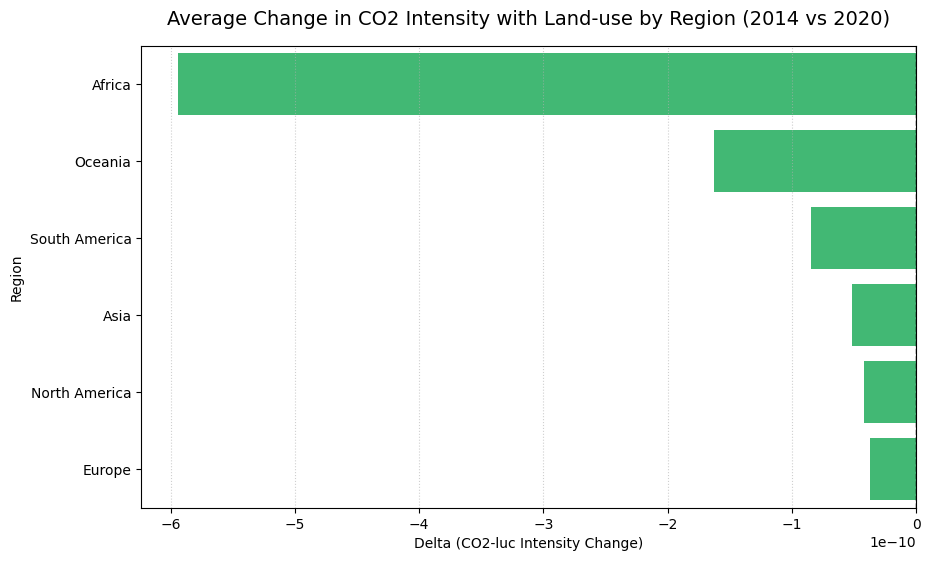

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# aggregating data y region (averaging or summing the delta)
region_luc_delta = endpoint_luc.groupby('region')['delta'].mean().sort_values().reset_index()

# Plotting
plt.figure(figsize=(10, 6))
# Fixing colors to show good or bad shift, green for negative delta (decline), red for positive (increase)
colors = ['#2ecc71' if x < 0 else '#e74c3c' for x in region_luc_delta['delta']]

sns.barplot(
    x='delta', 
    y='region', 
    data=region_luc_delta, 
    palette=colors
)

plt.axvline(x=0, color='black', linestyle='--', linewidth=1) # Zero line
plt.title('Average Change in CO2 Intensity with Land-use by Region (2014 vs 2020)', fontsize=14, pad=15)
plt.xlabel('Delta (CO2-luc Intensity Change)')
plt.ylabel('Region')
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.savefig('../figures/AvgChange_CO2intensLUC_Regions.png', dpi=150, bbox_inches='tight')
plt.show()

From the graph above it is clear that Africa has the highest drop in CO2 intensity, this is understandable as Africa baseline is the worst being the region with the extreme CO2 intensity outliers compared to the other regions. On the other hand, Europe has the lowest drop in CO2 intensity, which can be explained given that Europe is the greener region, starting already with a lower CO2 intensity to improve from.

In general, with the land-use metric it is visible that there have been improvements in the CO2 intensity, indicating that for all regions there has been certain level of decoupling of GDP and CO2 emissions.

Adding land-use change gives the complete picture of a country's actual carbon footprint.
Regions where co2_luc_int diverges significantly from co2_int are candidates for emissions displacement — growing without cutting, just changing the source.


### 2.3 Hypothesis 2: Renewable adoption vs. CO2 emissions

Where renewable energy adoption has grown, has CO₂ emissions actually fallen — and where is the gap largest?

In [37]:
#selecting just the columns of interest for the rewable and CO2 intensity change.
rs_cols=['country', 'year','region','co2','co2_luc','prct_renew_prod','prct_renew_cons']
rs_df=df[rs_cols]
rs_df.head(2)

,country,year,region,co2,co2_luc,prct_renew_prod,prct_renew_cons
0,Afghanistan,2014,Asia,8.697668,8.776041,2.77201,19.1
1,Afghanistan,2015,Asia,9.384400,9.696866,2.83229,17.7


In [38]:
# Region aggregation — sum CO2, mean renewable shares
region_trend = rs_df.groupby(['region', 'year']).agg(
    co2=('co2', 'sum'),
    renew_share=('prct_renew_cons', 'mean'),
    renew_prod=('prct_renew_prod', 'mean')
).reset_index()
region_trend.head(2)


,region,year,co2,renew_share,renew_prod
0,Africa,2014,1371.805383,58.692727,3.208046
1,Africa,2015,1348.717402,58.072727,4.065987


In [39]:
# Index all three to 2014 = 100
base_year = 2014
base = region_trend[region_trend['year'] == base_year][['region','co2','renew_share','renew_prod']]
base.columns = ['region','co2_base','renew_base','renew_prod_base']
base.head(2)


,region,co2_base,renew_base,renew_prod_base
0,Africa,1371.805383,58.692727,3.208046
7,Asia,18637.693147,18.972340,2.324469


In [40]:
region_trend = region_trend.merge(base, on='region')
region_trend.head(5)

,region,year,co2,renew_share,renew_prod,co2_base,renew_base,renew_prod_base
0,Africa,2014,1371.805383,58.692727,3.208046,1371.805383,58.692727,3.208046
1,Africa,2015,1348.717402,58.072727,4.065987,1371.805383,58.692727,3.208046
2,Africa,2016,1380.746971,57.521818,3.919330,1371.805383,58.692727,3.208046
3,Africa,2017,1390.820151,57.425455,3.906613,1371.805383,58.692727,3.208046
4,Africa,2018,1405.408923,56.998182,4.054775,1371.805383,58.692727,3.208046


In [41]:
#Now we compute the indexes given our base values from 2014
region_trend['co2_idx']       = (region_trend['co2']         / region_trend['co2_base'])       * 100
region_trend['renew_cons_idx'] = (region_trend['renew_share'] / region_trend['renew_base'])     * 100
region_trend['renew_prod_idx'] = (region_trend['renew_prod']  / region_trend['renew_prod_base'])* 100
region_trend.head(2)

,region,year,co2,renew_share,renew_prod,co2_base,renew_base,renew_prod_base,co2_idx,renew_cons_idx,renew_prod_idx
0,Africa,2014,1371.805383,58.692727,3.208046,1371.805383,58.692727,3.208046,100.000000,100.000000,100.000000
1,Africa,2015,1348.717402,58.072727,4.065987,1371.805383,58.692727,3.208046,98.316964,98.943651,126.743412


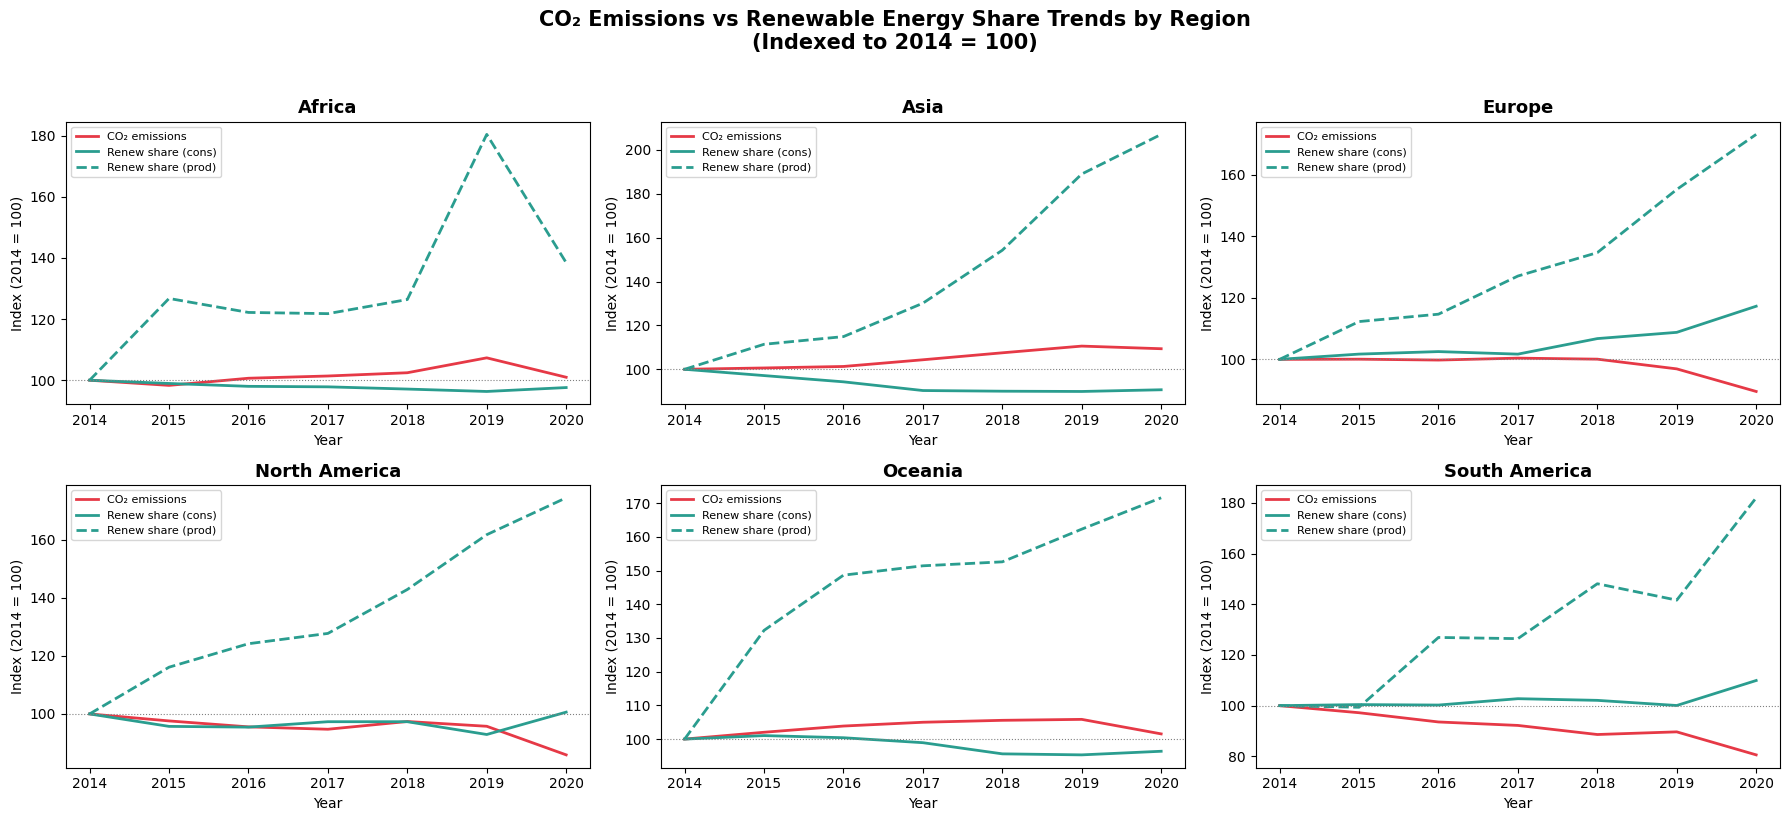

In [42]:
import matplotlib.pyplot as plt

regions = region_trend['region'].unique()
n = len(regions)
fig, axes = plt.subplots(nrows=(n+2)//3, ncols=3, figsize=(18, 4*((n+2)//3)), sharey=False)
axes = axes.flatten()

for i, region in enumerate(sorted(regions)):
    ax = axes[i]
    d = region_trend[region_trend['region'] == region]

    ax.plot(d['year'], d['co2_idx'],        color='#e63946', lw=2,   label='CO₂ emissions')
    ax.plot(d['year'], d['renew_cons_idx'], color='#2a9d8f', lw=2,   label='Renew share (cons)')
    ax.plot(d['year'], d['renew_prod_idx'], color='#2a9d8f', lw=2,   label='Renew share (prod)', linestyle='--')

    ax.axhline(100, color='grey', lw=0.8, linestyle=':')  # baseline reference
    ax.set_title(region, fontsize=13, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Index (2014 = 100)')
    ax.legend(fontsize=8)
    ax.set_xticks(d['year'].unique())

# hide empty subplots if regions < grid slots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('CO₂ Emissions vs Renewable Energy Share Trends by Region\n(Indexed to 2014 = 100)', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/h2_co2_vs_renew_trends.png', dpi=150, bbox_inches='tight')
plt.show()

From the graph above, we see that for every region the dynamic between renewable share and CO2 emissions is different. 

* **Renewables share not relieving CO2 emissions:**
For Africa, Asia and Oceania it shows that the renewable share production has increased however the CO2 emissions trend is not going down but instead also increasing. That hints that renewable energy production is not driving the CO2 emissions trend for those countries.

* **Renewables share better supports CO2 emissions decrease:**
Europe, North America and South America do show a closer relation between renewable share production vs CO2 emissions trend, although not seen for every year, but in general the CO2 emissions goes down while the renewable energy production increase.

* **The 'exporting clean energy' signal:**
For the regions Africa, Asia, Oceania and North America, the renewable production trend is different than the consumption, increasing the gap for most of the years, indicating that more renewable energy is being exported.

* **Overall read:** it's not possible to conclude that higher renewable production alone drives CO₂ intensity change. The trends vary too much by region, and the export dynamic muddies the picture.


#### 2.X Renewable adoption vs. CO2 intensity

In [43]:
#Sorting values to make sure they are organised chronologically

df= df.sort_values(['country', 'year']).reset_index(drop=True)
#since the scales of CO2 intensity are in tons and renewable production in percentage for each year, 
#we need to normalise to % change.

df['d_co2_int_pct'] = df.groupby('country')['co2_int'].pct_change()
df['d_renew_prod_pct'] = df.groupby('country')['prct_renew_prod'].pct_change()
df['d_renew_cons_pct'] = df.groupby('country')['prct_renew_cons'].pct_change()


In [44]:
df.head(1)

,country,year,prct_access_elec,prct_renew_prod,renew_prod_kwh,prct_renew_cons,co2,co2_luc,prim_ener_cons,region,GDP,population,gdp_per_cap,co2_int,d_co2_int,co2_luc_int,d_co2_int_pct,d_renew_prod_pct,d_renew_cons_pct
0,Afghanistan,2014,89.5,2.77201,32440000.0,19.1,8.697668,8.776041,26.630217,Asia,1.950046e+10,32792523.0,594.661805,4.460237e-10,NaN,4.500427e-10,NaN,NaN,NaN


In [45]:
#selecting just the columns of interest for the rewable and CO2 intensity change.
chg_cols=['country', 'year','region','d_co2_int_pct','d_renew_prod_pct','d_renew_cons_pct']
chg_df=df[chg_cols]
chg_df.head(5)

,country,year,region,d_co2_int_pct,d_renew_prod_pct,d_renew_cons_pct
0,Afghanistan,2014,Asia,NaN,NaN,NaN
1,Afghanistan,2015,Asia,0.125167,0.021746,-0.073298
2,Afghanistan,2016,Asia,-0.059040,0.126318,0.141243
3,Afghanistan,2017,Asia,0.035896,-0.006710,-0.034653
4,Afghanistan,2018,Asia,0.104891,0.096379,-0.061538


In [46]:
reg_chg = chg_df.groupby(['region','year'])[['d_co2_int_pct','d_renew_prod_pct','d_renew_cons_pct']].median().reset_index()


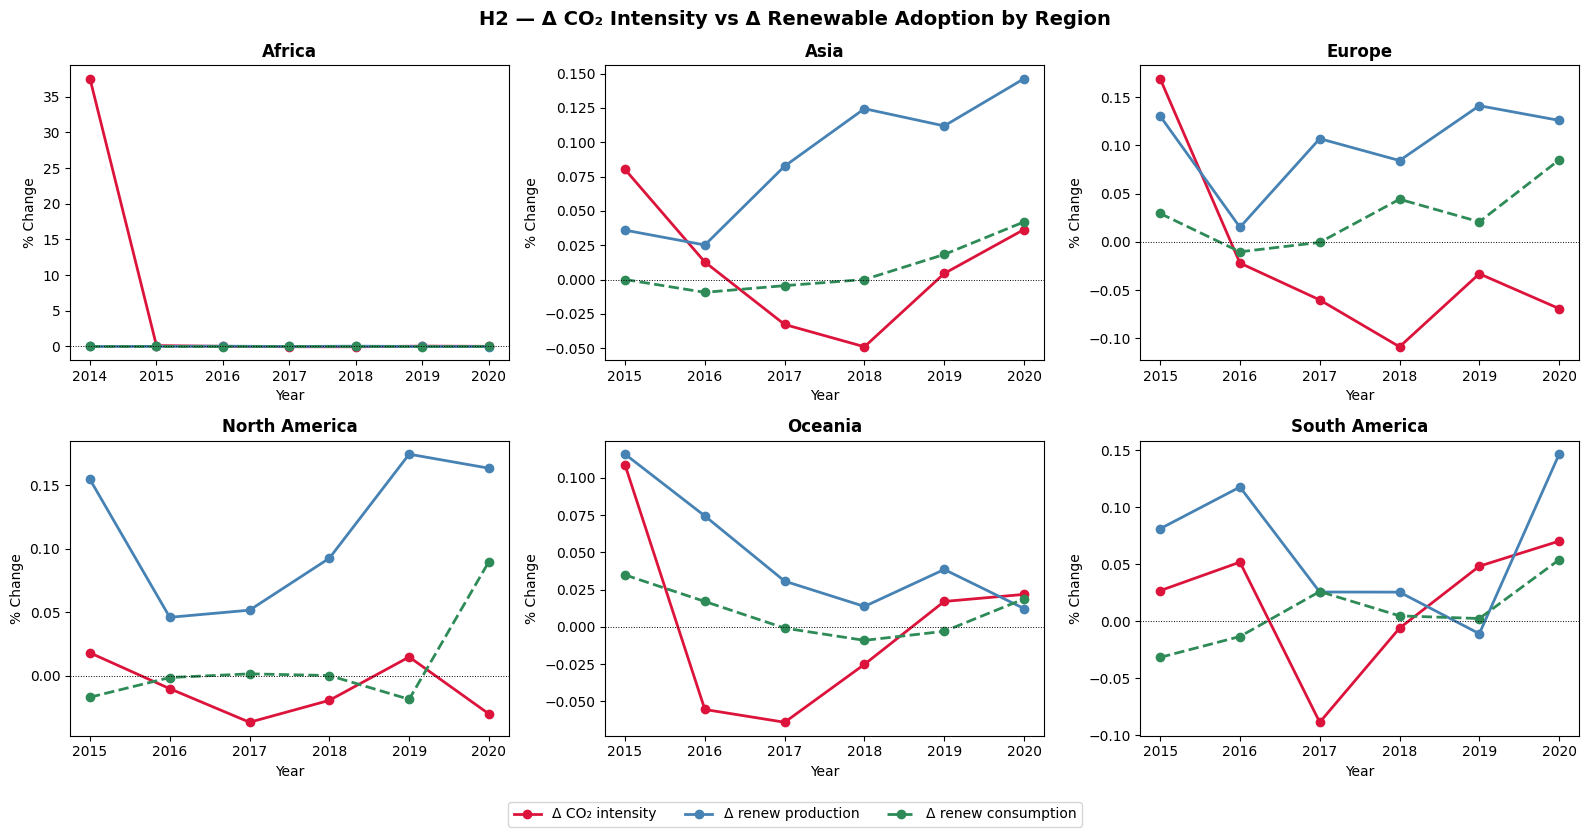

In [47]:
#To examine better the trends and compare, we plot each region separately.

regions = reg_chg['region'].unique()
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharey=False)
axes = axes.flatten()

for i, region in enumerate(regions):
    ax = axes[i]
    data = reg_chg[reg_chg['region'] == region]
    
    ax.plot(data['year'], data['d_co2_int_pct'],    color='crimson',  linewidth=2, marker='o', label='Δ CO₂ intensity')
    ax.plot(data['year'], data['d_renew_prod_pct'], color='steelblue', linewidth=2, marker='o', label='Δ renew production')
    ax.plot(data['year'], data['d_renew_cons_pct'], color='seagreen',  linewidth=2, marker='o', linestyle='--', label='Δ renew consumption')
    
    ax.axhline(0, color='black', linewidth=0.7, linestyle=':')
    ax.set_title(region, fontsize=12, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('% Change')

# shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.05))

plt.suptitle('H2 — Δ CO₂ Intensity vs Δ Renewable Adoption by Region', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/h2_regional_decoupling.png', dpi=150, bbox_inches='tight')
plt.show()

From the graph above:

* **Renewables driving decoupling:** this shows up when renewable production moves in the opposite direction to CO₂ intensity change. Visible for Asia [2016–2019], Europe [2016–2017], and briefly for South America. Not visible for North America or Oceania.

* **The 'exporting clean energy' signal:** a gap between production and consumption lines means the region is producing more renewables than it's consuming domestically — i.e. exporting the clean energy rather than using it to decarbonise at home. This shows up for Asia [2016–2018], Europe (especially 2018), North America [2016–2019], and slightly for South America in the final period.

* **Overall read:** it's not possible to conclude that higher renewable production alone drives CO₂ intensity change. The trends vary too much by region, and the export dynamic muddies the picture.

* **⚠️ Africa data:** something looks off. Africa's trend is outlier-sensitive and requires country-level decomposition before any regional claim holds


---
## 3. Summary of Findings

---

### Hypothesis 1 — CO₂ Intensity Decline

**Scenario A (fossil + industrial, co2_int):**
- CO₂ intensity declined across most regions between 2015 and 2018 — Europe showing the most consistent downward trend throughout the full 2014–2020 window.
- Asia holds the highest intensity levels by far and shows a sharp spike in 2019–2020.
- South America diverges upward after 2017, bucking the global pattern.
- The endpoint delta (2014 → 2020) confirms which regions ended lower or higher than they started.

**Scenario B (full footprint including land-use, co2_luc_int):**
- Adding land-use change gives the complete picture of a country's actual carbon footprint.
- Regions where co2_luc_int diverges significantly from co2_int are candidates for emissions displacement — growing without cutting, just changing the source.

**H1 Verdict :** 
- Partial decoupling is visible in some regions, specially for Europe over 2015–2020
- For all other regions partial decoupling happens for some periods only, but it's not sustained or universal. The 2019–2020 reversal in most regions complicates a clean decoupling narrative.
- Comparison  is counterintuitive: likely mechanism - land-use CO₂ (mostly deforestation) could peaked before 2014 and declined over the period, which pulls the full-footprint intensity down even as fossil emissions kept rising. So Scenario B could look "better" not because countries cleaned up, but because they cut fewer forests in 2020 than in 2014 — which is a very different thing from actual decoupling.


---

### Hypothesis 2 — Renewable Penetration as the Mechanism

- Renewable-to-CO₂ correlation is region- and period-specific: Europe, North America and South America do show clearer signals; Africa, Asia and Oceania  show none.
- The production/consumption gap reveals an export dynamic: some regions produce more renewables than they consume domestically. Specially for the regions Africa, Asia, Oceania and North America
  
- **H2 Verdict:** partially supported. Renewables are a contributing factor but not the sole driver.
- some regions show a widening gap between renewable production and consumption, suggesting clean energy is being exported rather than used to decarbonise domestic energy systems.

---

### 4. Known Limitations

- **GDP metric:** OWID PPP (2011 international $) — absolute intensity values are not current USD. Cross-country and time-series comparisons are valid, but headline numbers shouldn't be read as today's dollar values.
- **COVID 2020:** the CO₂ dip visible in some regions is partly driven by the economic contraction, not structural decoupling. This needs a caveat in H1 interpretation.
- **Africa data:** Africa's trend is outlier-sensitive and requires country-level decomposition before any regional claim holds.
- **H3 pending:** electricity access analysis not yet completed.

---



